In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import spectres

In [3]:
## -- load in fiducial transmission spectra:
## R100
waves100, wavehws100, depths100, deptherrs100 = np.loadtxt('./data/spectra/V1298Tauc_SOSS_LCtest2_6spots_R100.txt', skiprows=2, unpack=True)
depths100 *= 1.e6 # convert to (ppm)
deptherrs100 *= 1.e6
## R300
waves300, wavehws300, depths300, deptherrs300 = np.loadtxt('./data/spectra/V1298Tauc_SOSS_LCtest2_6spots_R300.txt', skiprows=2, unpack=True)
depths300 *= 1.e6 # convert to (ppm)
deptherrs300 *= 1.e6

## -- load in retrieval results:
## note that these are at R=300
## narrow (i.e. with priors) TLSE priors ('mp')
mp_waves, mp_med = np.loadtxt('./data/retrievals/star_narrow_priors/niriss_r300_lowm_star_priors-_TD_median_result.txt', unpack=True) # wavelength (um) and median model
mp_up1 = np.loadtxt('./data/retrievals/star_narrow_priors/niriss_r300_lowm_star_priors-_TD_high1sigma.txt', unpack=True)[1] # +1 sigma
mp_up2 = np.loadtxt('./data/retrievals/star_narrow_priors/niriss_r300_lowm_star_priors-_TD_high2sigma.txt', unpack=True)[1] # +2 sigma
mp_up3 = np.loadtxt('./data/retrievals/star_narrow_priors/niriss_r300_lowm_star_priors-_TD_high3sigma.txt', unpack=True)[1] # +3 sigma
mp_lo1 = np.loadtxt('./data/retrievals/star_narrow_priors/niriss_r300_lowm_star_priors-_TD_low1sigma.txt', unpack=True)[1] # -1 sigma
mp_lo2 = np.loadtxt('./data/retrievals/star_narrow_priors/niriss_r300_lowm_star_priors-_TD_low2sigma.txt', unpack=True)[1] # -2 sigma
mp_lo3 = np.loadtxt('./data/retrievals/star_narrow_priors/niriss_r300_lowm_star_priors-_TD_low3sigma.txt', unpack=True)[1] # -3 sigma

## wide (i.e. no priors) TLSE priors ('mn')
mn_waves, mn_med = np.loadtxt('./data/retrievals/star_wide_priors/niriss_r300_lowm-_TD_median_result.txt', unpack=True) # wavelength (um) and median model
mn_up1 = np.loadtxt('./data/retrievals/star_wide_priors/niriss_r300_lowm-_TD_high1sigma.txt', unpack=True)[1] # +1 sigma
mn_up2 = np.loadtxt('./data/retrievals/star_wide_priors/niriss_r300_lowm-_TD_high2sigma.txt', unpack=True)[1] # +2 sigma
mn_up3 = np.loadtxt('./data/retrievals/star_wide_priors/niriss_r300_lowm-_TD_high3sigma.txt', unpack=True)[1] # +3 sigma
mn_lo1 = np.loadtxt('./data/retrievals/star_wide_priors/niriss_r300_lowm-_TD_low1sigma.txt', unpack=True)[1] # -1 sigma
mn_lo2 = np.loadtxt('./data/retrievals/star_wide_priors/niriss_r300_lowm-_TD_low2sigma.txt', unpack=True)[1] # -2 sigma
mn_lo3 = np.loadtxt('./data/retrievals/star_wide_priors/niriss_r300_lowm-_TD_low3sigma.txt', unpack=True)[1] # -3 sigma

## -- resample retrieval results to obs grid, and convert to (ppm)
mp100_med = 1.e6*spectres.spectres(waves100, mp_waves, mp_med)
mp100_up1 = 1.e6*spectres.spectres(waves100, mp_waves, mp_up1)
mp100_up2 = 1.e6*spectres.spectres(waves100, mp_waves, mp_up2)
mp100_up3 = 1.e6*spectres.spectres(waves100, mp_waves, mp_up3)
mp100_lo1 = 1.e6*spectres.spectres(waves100, mp_waves, mp_lo1)
mp100_lo2 = 1.e6*spectres.spectres(waves100, mp_waves, mp_lo2)
mp100_lo3 = 1.e6*spectres.spectres(waves100, mp_waves, mp_lo3)

mn100_med = 1.e6*spectres.spectres(waves100, mn_waves, mn_med)
mn100_up1 = 1.e6*spectres.spectres(waves100, mn_waves, mn_up1)
mn100_up2 = 1.e6*spectres.spectres(waves100, mn_waves, mn_up2)
mn100_up3 = 1.e6*spectres.spectres(waves100, mn_waves, mn_up3)
mn100_lo1 = 1.e6*spectres.spectres(waves100, mn_waves, mn_lo1)
mn100_lo2 = 1.e6*spectres.spectres(waves100, mn_waves, mn_lo2)
mn100_lo3 = 1.e6*spectres.spectres(waves100, mn_waves, mn_lo3)

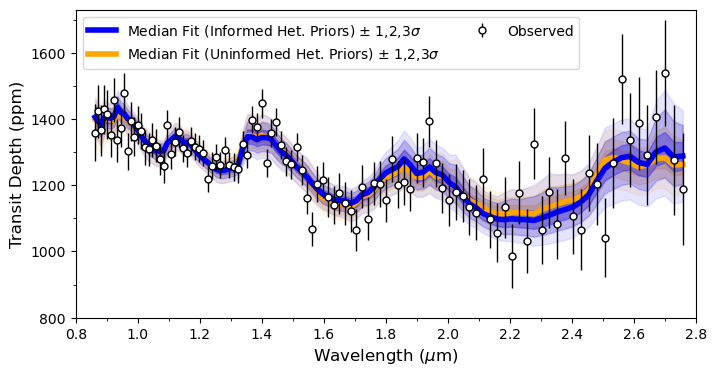

In [4]:
fig, ax = plt.subplots(figsize=(8,4))
# data:
ax.errorbar(waves100, depths100, deptherrs100, ls='None', lw=1, marker='o', ms=5, c='black', mfc='white', zorder=10, label='Observed')
# model with priors:
ax.plot(waves100, mp100_med, c='blue', lw=4, zorder=8, label=r'Median Fit (Informed Het. Priors) $\pm$ 1,2,3$\sigma$')
ax.fill_between(waves100, mp100_up1, mp100_lo1, fc='blue', ec='blue', alpha=0.3, zorder=6)
ax.fill_between(waves100, mp100_up2, mp100_lo2, fc='blue', ec='blue', alpha=0.2, zorder=5)
ax.fill_between(waves100, mp100_up3, mp100_lo3, fc='blue', ec='blue', alpha=0.1, zorder=4)
# model without priors:
ax.plot(waves100, mn100_med, c='orange', lw=4, zorder=6, label=r'Median Fit (Uninformed Het. Priors) $\pm$ 1,2,3$\sigma$')
ax.fill_between(waves100, mn100_up1, mn100_lo1, fc='orange', ec='orange', alpha=0.3, zorder=3)
ax.fill_between(waves100, mn100_up2, mn100_lo2, fc='orange', ec='orange', alpha=0.2, zorder=2)
ax.fill_between(waves100, mn100_up3, mn100_lo3, fc='orange', ec='orange', alpha=0.1, zorder=1)


ax.set_xlabel(r'Wavelength ($\mu$m)', fontsize=12)
ax.xaxis.set_major_locator(MultipleLocator(0.2))
ax.xaxis.set_minor_locator(MultipleLocator(0.1))
ax.set_ylabel(r'Transit Depth (ppm)', fontsize=12)
ax.yaxis.set_major_locator(MultipleLocator(200))
ax.yaxis.set_minor_locator(MultipleLocator(100))
ax.legend(loc='upper left', ncol=2)
ax.set_ylim(800,1730)
ax.set_xlim(0.8,2.8)
plt.savefig('./figures/Figure4.png', dpi=600, bbox_inches='tight')
plt.show()